# Project 3: Global Mental Health Crisis Index 2026

## Project Overview

This notebook explores the **Global Mental Health Crisis Index 2026** dataset, which covers **92 countries** and **29 indicators** related to mental health burden, healthcare systems, policy, digital behavior, and socioeconomic context.

The goal is to **showcase five potential use cases** from the project brief, with **one additional bonus use case**. The notebook combines **Exploratory Data Analysis (EDA)** and **Confirmatory Data Analysis (CDA)**:

- **EDA** is used to understand distributions, compare countries and regions, and detect broad patterns.
- **CDA** is used to test whether selected relationships are statistically meaningful.

### Questions covered in this notebook

1. Which WHO regions have the highest average mental health crisis burden?
2. Is heavier social media use associated with worse mental health outcomes?
3. Which regions experienced the strongest estimated post-COVID mental health increase?
4. Do countries with mental health policy or law frameworks show smaller treatment gaps?
5. How do mental health outcomes differ across income groups?
6. **Bonus:** Can countries be grouped into distinct mental health system profiles using clustering?

### Expected outcome

By the end of the notebook, we will identify the strongest visible global patterns in crisis severity, treatment access, policy coverage, and system strength, then summarize what these results could mean for policymakers and researchers.


## Setup

This section groups all imports, display settings, helper functions, and configuration variables at the top of the notebook so the analysis stays reproducible and easy to follow, as required by the bootcamp notebook guidelines.

In [2]:

# Standard library
from pathlib import Path
import warnings

# Installed libraries
from IPython.display import Markdown, display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu, kruskal
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import kagglehub

# Display and plotting configuration
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Dataset identifiers
KAGGLE_DATASET = "alitaqishah/global-mental-health-crisis-index-2026"
CSV_NAME = "Global_Mental_Health_Crisis_Index_2026.csv"


def add_value_labels(ax, fmt="{:.1f}"):
    # \"\"\"Add value labels on top of bars in a matplotlib/seaborn bar chart.\"\"\"
    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height):
            ax.annotate(
                fmt.format(height),
                (p.get_x() + p.get_width() / 2, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 4),
                textcoords="offset points"
            )


def print_test_result(test_name, statistic, p_value, alpha=0.05):
    # \"\"\"Print a compact interpretation for a statistical test.\"\"\"
    print(f"{test_name}")
    print(f"Statistic: {statistic:.4f}")
    print(f"p-value: {p_value:.4f}")
    if p_value < alpha:
        print(f"Result: Statistically significant at alpha = {alpha}")
    else:
        print(f"Result: Not statistically significant at alpha = {alpha}")


/Users/abdulazizalmousa/Desktop/SDAIA bootcamp/B5/content/W2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading

The project instructions explicitly ask to download the dataset using `kagglehub`. The code below follows that format, then searches for the CSV file safely in case the folder structure differs slightly across environments.

In [3]:

# Download latest version from Kaggle
dataset_path = kagglehub.dataset_download(KAGGLE_DATASET)
print("Path to dataset files:", dataset_path)

# Resolve CSV path robustly
dataset_dir = Path(dataset_path)
candidate_files = list(dataset_dir.rglob("*.csv"))

if not candidate_files:
    raise FileNotFoundError("No CSV file was found in the downloaded dataset directory.")

csv_path = None
for file in candidate_files:
    if file.name == CSV_NAME:
        csv_path = file
        break

if csv_path is None:
    csv_path = candidate_files[0]

print("CSV selected:", csv_path)

# Load the dataset
df = pd.read_csv(csv_path)


100%|██████████| 5.42k/5.42k [00:00<00:00, 4.05MB/s]

Extracting files...
Path to dataset files: /Users/abdulazizalmousa/.cache/kagglehub/datasets/alitaqishah/global-mental-health-crisis-index-2026/versions/1
CSV selected: /Users/abdulazizalmousa/.cache/kagglehub/datasets/alitaqishah/global-mental-health-crisis-index-2026/versions/1/Global_Mental_Health_Crisis_Index_2026.csv


## Data Loading and Quick Validation

Before any analysis, we validate the dataset structure. This catches loading issues early and confirms that the file matches the project description.

In [4]:

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())


Dataset shape: (92, 29)

Column names:
['country', 'iso3', 'region', 'income_group', 'depression_pct', 'anxiety_pct', 'suicide_rate_per100k', 'psychiatrists_per100k', 'mh_budget_pct_health', 'mh_spend_usd_per_capita', 'treatment_gap_pct', 'social_media_hours_daily', 'internet_penetration_pct', 'gdp_per_capita_usd', 'population_millions', 'covid_mh_increase_pct', 'youth_mh_crisis_score', 'mh_policy_exists', 'mh_law_exists', 'mh_crisis_index', 'total_affected_millions', 'psychiatrists_per_million', 'mh_investment_gap', 'social_media_mental_health_risk', 'depression_anxiety_comorbidity_est_pct', 'mh_system_score', 'income_group_code', 'data_year', 'data_source']

Data types:


country                                       str
iso3                                          str
region                                        str
income_group                                  str
depression_pct                            float64
anxiety_pct                               float64
suicide_rate_per100k                      float64
psychiatrists_per100k                     float64
mh_budget_pct_health                      float64
mh_spend_usd_per_capita                   float64
treatment_gap_pct                           int64
social_media_hours_daily                  float64
internet_penetration_pct                    int64
gdp_per_capita_usd                          int64
population_millions                       float64
covid_mh_increase_pct                       int64
youth_mh_crisis_score                     float64
mh_policy_exists                              str
mh_law_exists                                 str
mh_crisis_index                             int64



First 5 rows:


,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,treatment_gap_pct,social_media_hours_daily,internet_penetration_pct,gdp_per_capita_usd,population_millions,covid_mh_increase_pct,youth_mh_crisis_score,mh_policy_exists,mh_law_exists,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,social_media_mental_health_risk,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year,data_source
0,Malawi,MWI,Africa,Low,3.30,4.50,6.50,0.02,0.80,0.10,97,1.10,16,700,20.40,86,9.50,No,No,87,1.59,0.20,0.08,Low (<1.5h),1.65,3.40,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
1,Mozambique,MOZ,Africa,Low,3.40,4.60,8.20,0.04,0.60,0.10,96,1.20,18,600,32.80,85,9.40,No,No,86,2.62,0.40,0.06,Low (<1.5h),1.70,3.10,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
2,Ethiopia,ETH,Africa,Low,3.50,4.80,10.20,0.04,1.00,0.10,95,1.40,22,1200,123.40,82,9.30,No,No,84,10.24,0.40,0.10,Low (<1.5h),1.75,4.70,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
3,Zimbabwe,ZWE,Africa,Low,4.00,5.20,15.40,0.05,0.70,0.10,94,2.10,35,1000,15.90,82,9.30,No,No,83,1.46,0.50,0.07,Moderate (1.5-2.5h),2.00,4.10,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
4,Tanzania,TZA,Africa,Low,3.60,4.90,8.60,0.04,0.80,0.10,94,1.60,28,1200,65.50,80,9.20,No,No,82,5.57,0.40,0.07,Moderate (1.5-2.5h),1.80,4.40,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...


The dataset should contain **92 rows**, where each row represents one country. At this stage we verify the structure, inspect the variable names, and confirm whether the data appears analysis-ready.

In [5]:

print("Missing values by column:")
display(df.isnull().sum().sort_values(ascending=False))

print("Duplicate rows:", df.duplicated().sum())

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))


Missing values by column:


country                                   0
covid_mh_increase_pct                     0
data_year                                 0
income_group_code                         0
mh_system_score                           0
depression_anxiety_comorbidity_est_pct    0
social_media_mental_health_risk           0
mh_investment_gap                         0
psychiatrists_per_million                 0
total_affected_millions                   0
mh_crisis_index                           0
mh_law_exists                             0
mh_policy_exists                          0
youth_mh_crisis_score                     0
population_millions                       0
iso3                                      0
gdp_per_capita_usd                        0
internet_penetration_pct                  0
social_media_hours_daily                  0
treatment_gap_pct                         0
mh_spend_usd_per_capita                   0
mh_budget_pct_health                      0
psychiatrists_per100k           

Duplicate rows: 0
Number of numeric columns: 21
Number of categorical columns: 8


## Descriptive Statistics Summary

This section provides a compact statistical snapshot of the numeric variables so we can understand their scale, spread, and typical values before moving into the use cases.

In [6]:

display(df[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
depression_pct,92.00,4.40,0.75,2.90,3.80,4.40,4.90,6.30
anxiety_pct,92.00,5.63,1.20,3.80,4.80,5.20,6.10,9.30
suicide_rate_per100k,92.00,11.56,9.83,3.20,7.57,9.80,12.82,87.50
psychiatrists_per100k,92.00,7.18,9.49,0.02,0.50,3.15,12.45,54.90
mh_budget_pct_health,92.00,3.76,2.96,0.60,1.20,2.85,5.65,11.30
mh_spend_usd_per_capita,92.00,38.95,63.42,0.10,0.73,8.00,49.75,320.00
treatment_gap_pct,92.00,58.93,27.88,17.00,26.00,64.50,84.50,97.00
social_media_hours_daily,92.00,2.21,0.79,0.10,1.60,2.10,2.80,4.80
internet_penetration_pct,92.00,73.75,24.26,8.00,68.75,82.50,92.25,99.00
gdp_per_capita_usd,92.00,"22,231.61","25,685.34",600.00,"3,975.00","10,150.00","33,975.00","106,900.00"


## Lightweight Feature Preparation

The dataset is described as having no missing values, so we do not need heavy cleaning. However, a few columns such as policy and law status are easier to analyze after converting `Yes/No` values into numeric flags. We keep the original columns and create additional helper columns for analysis.

In [7]:

df_analysis = df.copy()

binary_map = {"Yes": 1, "No": 0}

for col in ["mh_policy_exists", "mh_law_exists"]:
    if col in df_analysis.columns:
        df_analysis[f"{col}_flag"] = df_analysis[col].map(binary_map)

display(df_analysis.head())


,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,treatment_gap_pct,social_media_hours_daily,internet_penetration_pct,gdp_per_capita_usd,population_millions,covid_mh_increase_pct,youth_mh_crisis_score,mh_policy_exists,mh_law_exists,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,social_media_mental_health_risk,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year,data_source,mh_policy_exists_flag,mh_law_exists_flag
0,Malawi,MWI,Africa,Low,3.30,4.50,6.50,0.02,0.80,0.10,97,1.10,16,700,20.40,86,9.50,No,No,87,1.59,0.20,0.08,Low (<1.5h),1.65,3.40,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,0,0
1,Mozambique,MOZ,Africa,Low,3.40,4.60,8.20,0.04,0.60,0.10,96,1.20,18,600,32.80,85,9.40,No,No,86,2.62,0.40,0.06,Low (<1.5h),1.70,3.10,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,0,0
2,Ethiopia,ETH,Africa,Low,3.50,4.80,10.20,0.04,1.00,0.10,95,1.40,22,1200,123.40,82,9.30,No,No,84,10.24,0.40,0.10,Low (<1.5h),1.75,4.70,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,0,0
3,Zimbabwe,ZWE,Africa,Low,4.00,5.20,15.40,0.05,0.70,0.10,94,2.10,35,1000,15.90,82,9.30,No,No,83,1.46,0.50,0.07,Moderate (1.5-2.5h),2.00,4.10,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,0,0
4,Tanzania,TZA,Africa,Low,3.60,4.90,8.60,0.04,0.80,0.10,94,1.60,28,1200,65.50,80,9.20,No,No,82,5.57,0.40,0.07,Moderate (1.5-2.5h),1.80,4.40,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...,0,0


# Use Case 1: Visualization and Dashboards
## Regional comparison of mental health crisis severity

We begin with a regional comparison because it gives a high-level dashboard view of where mental health burden appears highest. This is a useful first step for policymakers because it quickly shows where the average crisis score is most elevated.

In [8]:

regional_crisis = (
    df_analysis.groupby("region")["mh_crisis_index"]
    .agg(["mean", "median", "count"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

display(regional_crisis)


,region,mean,median,count
0,Africa,78.21,79.50,14
4,S-E Asia,65.55,66.00,11
2,E. Med,61.00,65.00,9
1,Americas,59.08,60.00,13
5,W. Pacific,52.62,45.00,13
3,Europe,48.31,47.00,32


A summary table is useful, but a chart makes regional differences easier to interpret visually.

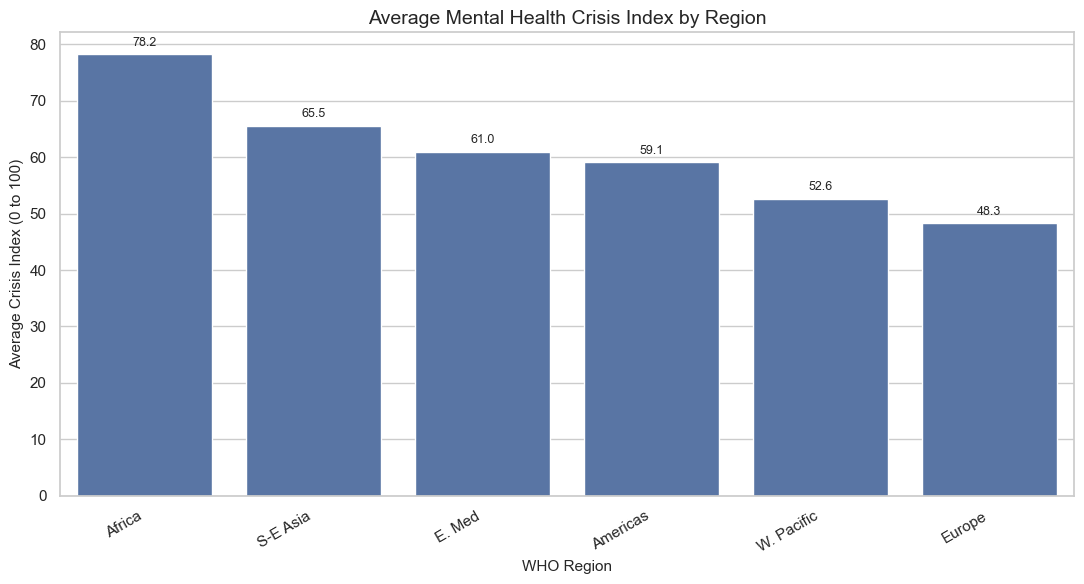

In [9]:

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=regional_crisis,
    x="region",
    y="mean"
)
add_value_labels(ax)
ax.set_title("Average Mental Health Crisis Index by Region")
ax.set_xlabel("WHO Region")
ax.set_ylabel("Average Crisis Index (0 to 100)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Interpretation

The next cell turns the regional table into a direct finding by identifying the highest-burden region and the gap between the top and bottom regional averages.

In [10]:
top_region = regional_crisis.iloc[0]["region"]
top_score = regional_crisis.iloc[0]["mean"]
bottom_region = regional_crisis.iloc[-1]["region"]
bottom_score = regional_crisis.iloc[-1]["mean"]
gap = top_score - bottom_score

display(Markdown(
    f"**Finding.** `{top_region}` recorded the highest average mental health crisis index at "
    f"**{top_score:.2f}**, while `{bottom_region}` recorded the lowest at **{bottom_score:.2f}**. "
    f"The gap between them was **{gap:.2f}** points, showing a clear regional difference in average crisis burden."
))

**Finding.** `Africa` recorded the highest average mental health crisis index at **78.21**, while `Europe` recorded the lowest at **48.31**. The gap between them was **29.90** points, showing a clear regional difference in average crisis burden.

# Use Case 2: Social Media and Mental Health
## Is greater daily social media use associated with worse outcomes?

The project brief specifically highlights the digital environment. To explore this, we test whether countries with more daily social media exposure also tend to report higher depression rates and higher crisis scores.

Because these are country-level variables and the relationship may not be perfectly linear, we use **Spearman correlation**, which captures monotonic association more robustly than Pearson correlation.

In [11]:

social_cols = ["social_media_hours_daily", "depression_pct", "mh_crisis_index"]
display(df_analysis[social_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
social_media_hours_daily,92.00,2.21,0.79,0.10,1.60,2.10,2.80,4.80
depression_pct,92.00,4.40,0.75,2.90,3.80,4.40,4.90,6.30
mh_crisis_index,92.00,58.29,13.64,36.00,45.75,58.00,69.00,87.00


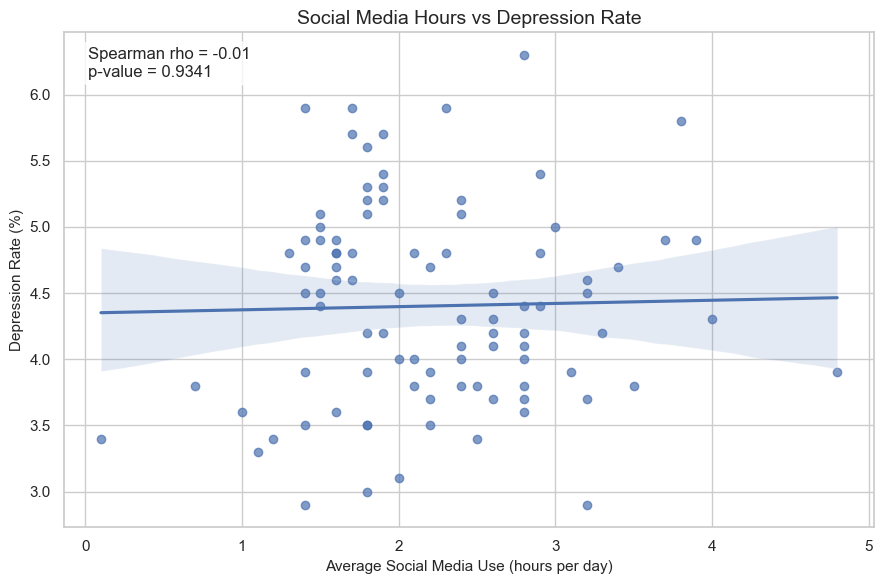

Spearman test: Social media hours vs depression rate
Statistic: -0.0087
p-value: 0.9341
Result: Not statistically significant at alpha = 0.05


In [12]:

plt.figure(figsize=(9, 6))
ax = sns.regplot(
    data=df_analysis,
    x="social_media_hours_daily",
    y="depression_pct",
    scatter_kws={"alpha": 0.7}
)
ax.set_title("Social Media Hours vs Depression Rate")
ax.set_xlabel("Average Social Media Use (hours per day)")
ax.set_ylabel("Depression Rate (%)")

rho_dep, p_dep = spearmanr(
    df_analysis["social_media_hours_daily"],
    df_analysis["depression_pct"]
)
ax.text(
    0.03, 0.97,
    f"Spearman rho = {rho_dep:.2f}\np-value = {p_dep:.4f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

print_test_result("Spearman test: Social media hours vs depression rate", rho_dep, p_dep)


The scatter plot shows whether countries with greater daily social media use also tend to have higher depression prevalence. The Spearman result tells us whether that overall trend is statistically meaningful, not just visually suggestive.

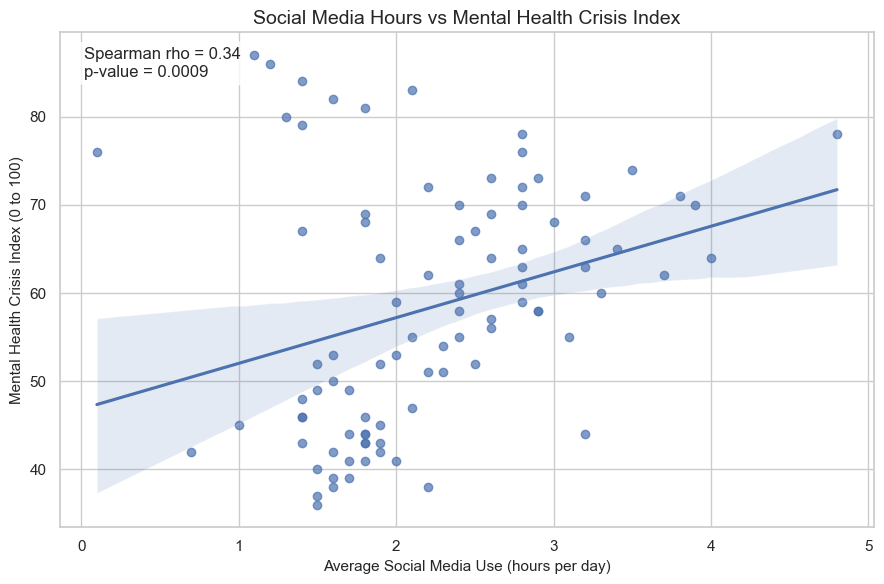

Spearman test: Social media hours vs crisis index
Statistic: 0.3396
p-value: 0.0009
Result: Statistically significant at alpha = 0.05


In [13]:

plt.figure(figsize=(9, 6))
ax = sns.regplot(
    data=df_analysis,
    x="social_media_hours_daily",
    y="mh_crisis_index",
    scatter_kws={"alpha": 0.7}
)
ax.set_title("Social Media Hours vs Mental Health Crisis Index")
ax.set_xlabel("Average Social Media Use (hours per day)")
ax.set_ylabel("Mental Health Crisis Index (0 to 100)")

rho_crisis, p_crisis = spearmanr(
    df_analysis["social_media_hours_daily"],
    df_analysis["mh_crisis_index"]
)
ax.text(
    0.03, 0.97,
    f"Spearman rho = {rho_crisis:.2f}\np-value = {p_crisis:.4f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

print_test_result("Spearman test: Social media hours vs crisis index", rho_crisis, p_crisis)


### Interpretation

The next cell reports the exact Spearman results and states whether the observed associations are statistically significant at the 5% level.

In [14]:
dep_sig = "statistically significant" if p_dep < 0.05 else "not statistically significant"
crisis_sig = "statistically significant" if p_crisis < 0.05 else "not statistically significant"

display(Markdown(
    f"**Finding.** The association between daily social media use and depression rate was "
    f"**rho = {rho_dep:.3f}** with **p = {p_dep:.4f}**, which is **{dep_sig}** at the 5% level. "
    f"The association between daily social media use and overall crisis index was "
    f"**rho = {rho_crisis:.3f}** with **p = {p_crisis:.4f}**, which is **{crisis_sig}**."
))

**Finding.** The association between daily social media use and depression rate was **rho = -0.009** with **p = 0.9341**, which is **not statistically significant** at the 5% level. The association between daily social media use and overall crisis index was **rho = 0.340** with **p = 0.0009**, which is **statistically significant**.

# Use Case 3: COVID-19 Aftermath
## Which regions saw the largest post-pandemic increase?

The dataset includes an estimated increase in mental health burden after COVID-19. This lets us compare which regions appear to have experienced the strongest pandemic-era surge.

In [15]:

regional_covid = (
    df_analysis.groupby("region", as_index=False)["covid_mh_increase_pct"]
    .mean()
    .sort_values("covid_mh_increase_pct", ascending=False)
)

display(regional_covid)


,region,covid_mh_increase_pct
0,Africa,74.07
4,S-E Asia,58.00
2,E. Med,54.44
1,Americas,49.38
5,W. Pacific,45.08
3,Europe,36.66


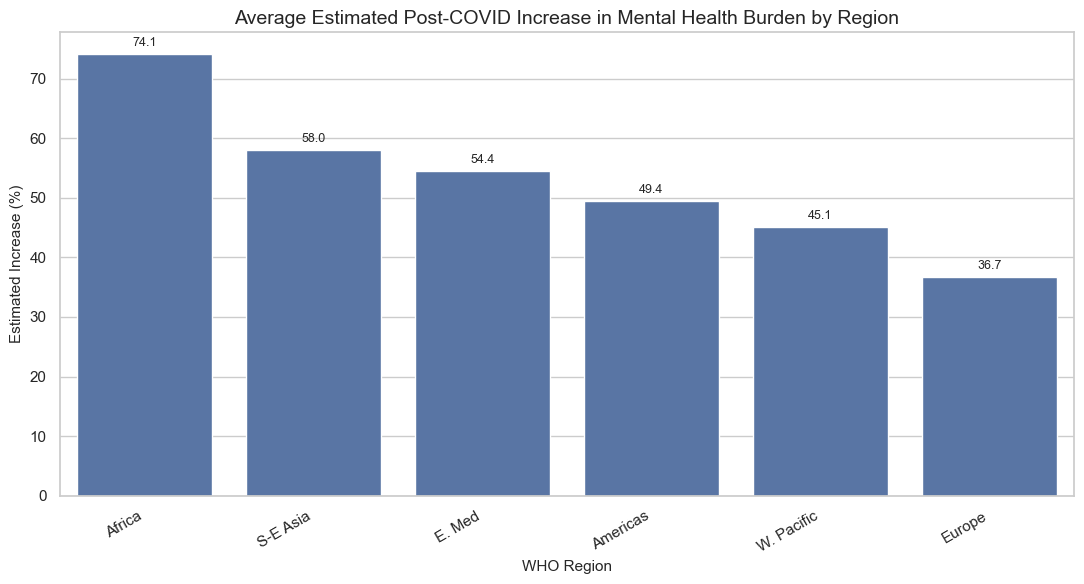

In [16]:

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=regional_covid,
    x="region",
    y="covid_mh_increase_pct"
)
add_value_labels(ax)
ax.set_title("Average Estimated Post-COVID Increase in Mental Health Burden by Region")
ax.set_xlabel("WHO Region")
ax.set_ylabel("Estimated Increase (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Immediate regional takeaway

The next cell extracts the region with the largest average estimated post-COVID increase so the bar chart is followed by a direct result, not only a visual description.

In [17]:
top_covid_region = regional_covid.iloc[0]
bottom_covid_region = regional_covid.iloc[-1]

display(Markdown(
    f"**Finding.** `{top_covid_region['region']}` had the highest average estimated post-COVID "
    f"increase in mental health burden at **{top_covid_region['covid_mh_increase_pct']:.2f}%**, "
    f"while `{bottom_covid_region['region']}` had the lowest at "
    f"**{bottom_covid_region['covid_mh_increase_pct']:.2f}%**."
))

**Finding.** `Africa` had the highest average estimated post-COVID increase in mental health burden at **74.07%**, while `Europe` had the lowest at **36.66%**.

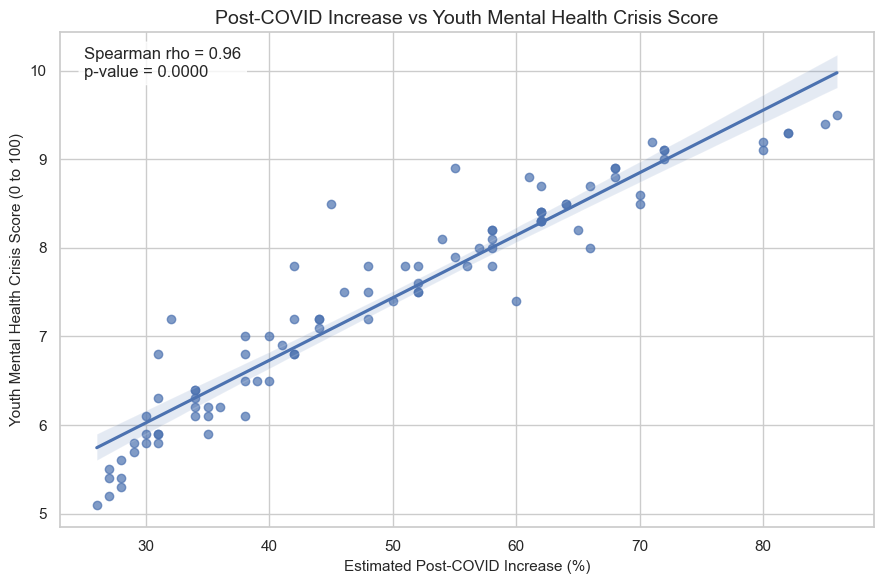

Spearman test: Post-COVID increase vs youth crisis score
Statistic: 0.9616
p-value: 0.0000
Result: Statistically significant at alpha = 0.05


In [18]:

plt.figure(figsize=(9, 6))
ax = sns.regplot(
    data=df_analysis,
    x="covid_mh_increase_pct",
    y="youth_mh_crisis_score",
    scatter_kws={"alpha": 0.7}
)
ax.set_title("Post-COVID Increase vs Youth Mental Health Crisis Score")
ax.set_xlabel("Estimated Post-COVID Increase (%)")
ax.set_ylabel("Youth Mental Health Crisis Score (0 to 100)")

rho_youth, p_youth = spearmanr(
    df_analysis["covid_mh_increase_pct"],
    df_analysis["youth_mh_crisis_score"]
)
ax.text(
    0.03, 0.97,
    f"Spearman rho = {rho_youth:.2f}\np-value = {p_youth:.4f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

print_test_result("Spearman test: Post-COVID increase vs youth crisis score", rho_youth, p_youth)


### Interpretation

The next cell combines the COVID-youth correlation output into a concise conclusion using the computed statistic and p-value.

In [19]:
youth_sig = "statistically significant" if p_youth < 0.05 else "not statistically significant"

display(Markdown(
    f"**Finding.** The relationship between estimated post-COVID mental health increase and youth "
    f"mental health crisis score was **rho = {rho_youth:.3f}** with **p = {p_youth:.4f}**, "
    f"which is **{youth_sig}** at the 5% level."
))

**Finding.** The relationship between estimated post-COVID mental health increase and youth mental health crisis score was **rho = 0.962** with **p = 0.0000**, which is **statistically significant** at the 5% level.

# Use Case 4: Policy Analysis
## Do policy and legal frameworks relate to smaller treatment gaps?

The dataset includes two governance variables:

- `mh_policy_exists`
- `mh_law_exists`

A natural policy question is whether countries with a policy or law framework tend to have **lower treatment gaps**. Since treatment gap percentages may not be normally distributed and group sizes may differ, we use the **Mann-Whitney U test**, a non-parametric test for comparing two independent groups.

In [20]:

policy_gap_summary = (
    df_analysis.groupby("mh_policy_exists")["treatment_gap_pct"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

law_gap_summary = (
    df_analysis.groupby("mh_law_exists")["treatment_gap_pct"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

print("Treatment gap by mental health policy status")
display(policy_gap_summary)

print("Treatment gap by mental health law status")
display(law_gap_summary)


Treatment gap by mental health policy status


,mh_policy_exists,mean,median,count
0,No,89.30,90.00,20
1,Yes,50.50,54.50,72


Treatment gap by mental health law status


,mh_law_exists,mean,median,count
0,No,89.46,90.00,24
1,Yes,48.16,50.00,68


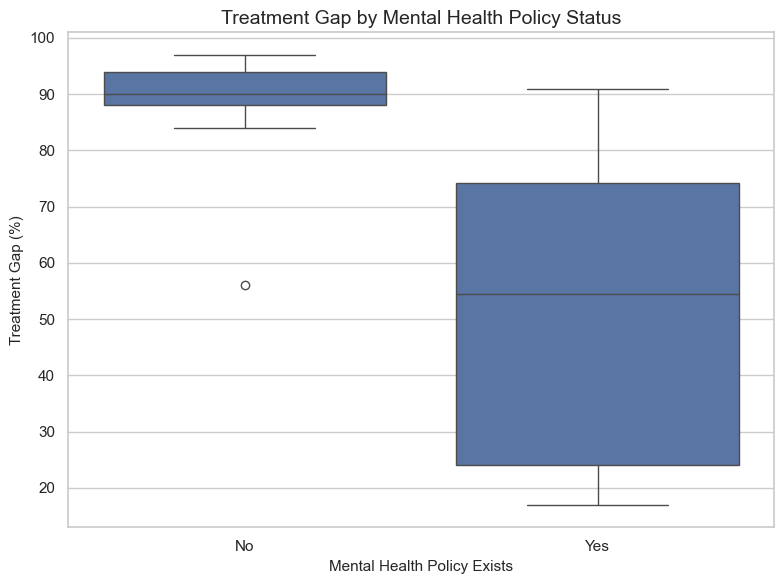

Mann-Whitney U test: Treatment gap by policy status
Statistic: 62.0000
p-value: 0.0000
Result: Statistically significant at alpha = 0.05


In [21]:

plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    data=df_analysis,
    x="mh_policy_exists",
    y="treatment_gap_pct"
)
ax.set_title("Treatment Gap by Mental Health Policy Status")
ax.set_xlabel("Mental Health Policy Exists")
ax.set_ylabel("Treatment Gap (%)")
plt.tight_layout()
plt.show()

policy_yes = df_analysis.loc[df_analysis["mh_policy_exists"] == "Yes", "treatment_gap_pct"]
policy_no = df_analysis.loc[df_analysis["mh_policy_exists"] == "No", "treatment_gap_pct"]

u_policy, p_policy = mannwhitneyu(policy_yes, policy_no, alternative="two-sided")
print_test_result("Mann-Whitney U test: Treatment gap by policy status", u_policy, p_policy)


The box plot helps compare the full spread of treatment gaps in policy vs non-policy countries, not just their averages. The Mann-Whitney test checks whether the difference between the two groups is statistically meaningful.

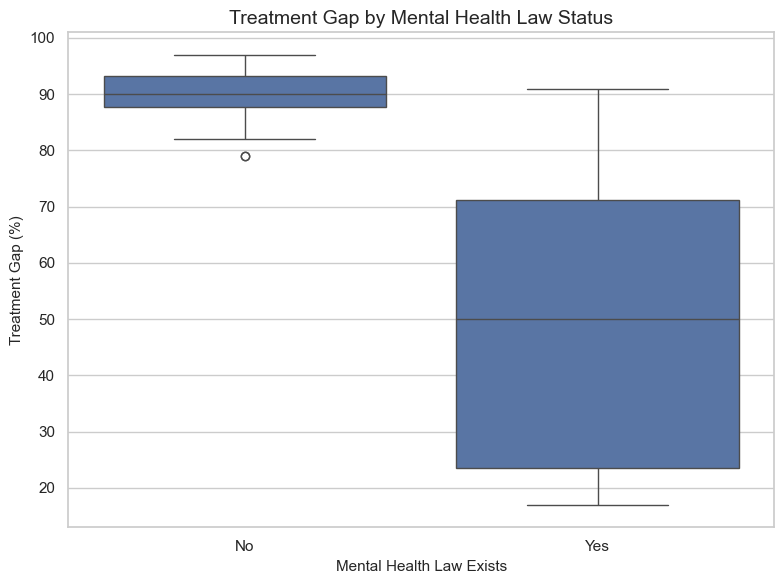

Mann-Whitney U test: Treatment gap by law status
Statistic: 42.5000
p-value: 0.0000
Result: Statistically significant at alpha = 0.05


In [22]:

plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    data=df_analysis,
    x="mh_law_exists",
    y="treatment_gap_pct"
)
ax.set_title("Treatment Gap by Mental Health Law Status")
ax.set_xlabel("Mental Health Law Exists")
ax.set_ylabel("Treatment Gap (%)")
plt.tight_layout()
plt.show()

law_yes = df_analysis.loc[df_analysis["mh_law_exists"] == "Yes", "treatment_gap_pct"]
law_no = df_analysis.loc[df_analysis["mh_law_exists"] == "No", "treatment_gap_pct"]

u_law, p_law = mannwhitneyu(law_yes, law_no, alternative="two-sided")
print_test_result("Mann-Whitney U test: Treatment gap by law status", u_law, p_law)


### Interpretation

The next cell summarizes the policy and law comparisons using the observed medians and the Mann-Whitney test results.

In [23]:
policy_sig = "statistically significant" if p_policy < 0.05 else "not statistically significant"
law_sig = "statistically significant" if p_law < 0.05 else "not statistically significant"

display(Markdown(
    f"**Finding.** Countries with a mental health policy had a median treatment gap of "
    f"**{policy_yes.median():.2f}%** compared with **{policy_no.median():.2f}%** in countries "
    f"without one. The Mann-Whitney test returned **p = {p_policy:.4f}**, so this difference is "
    f"**{policy_sig}**. Countries with a mental health law had a median treatment gap of "
    f"**{law_yes.median():.2f}%** versus **{law_no.median():.2f}%** without one, with "
    f"**p = {p_law:.4f}**, which is **{law_sig}**."
))

**Finding.** Countries with a mental health policy had a median treatment gap of **54.50%** compared with **90.00%** in countries without one. The Mann-Whitney test returned **p = 0.0000**, so this difference is **statistically significant**. Countries with a mental health law had a median treatment gap of **50.00%** versus **90.00%** without one, with **p = 0.0000**, which is **statistically significant**.

# Use Case 5: Inequality Research
## Comparing high-income vs low-income country disparities

Income group differences are central to global inequality research. Here we compare crisis burden, treatment gaps, and system capacity across `income_group` categories.

Because there are more than two groups, we use the **Kruskal-Wallis test** to check whether at least one income group differs significantly from the others.

In [24]:

income_summary = (
    df_analysis.groupby("income_group")[["mh_crisis_index", "treatment_gap_pct", "psychiatrists_per100k", "mh_system_score"]]
    .mean()
    .sort_values("mh_crisis_index", ascending=False)
)

display(income_summary)


,mh_crisis_index,treatment_gap_pct,psychiatrists_per100k,mh_system_score
income_group,,,,
Low,81.38,94.25,0.10,4.49
Lower-Middle,68.81,84.04,0.62,10.10
Upper-Middle,59.65,66.65,3.62,22.89
High,44.31,27.14,16.02,63.07


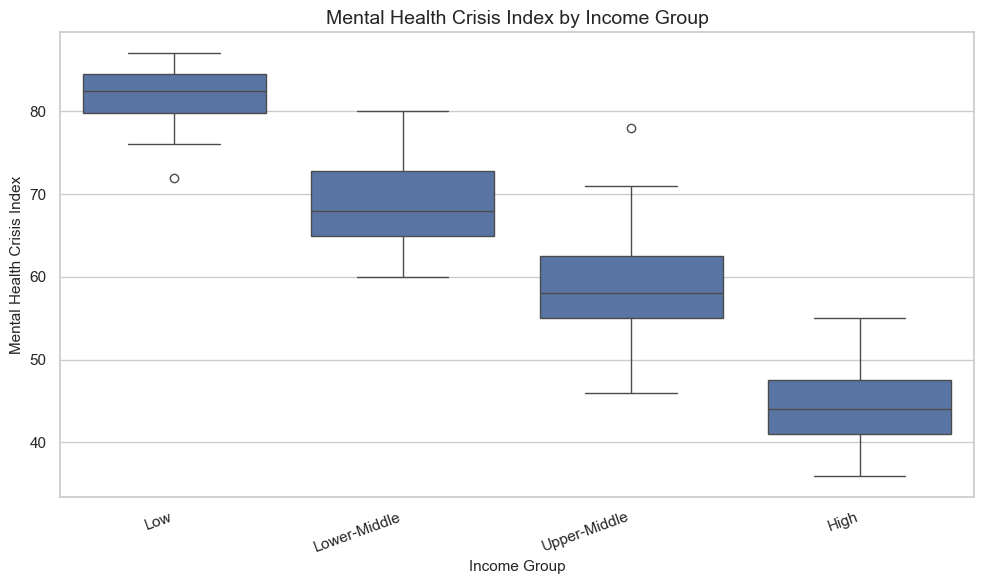

Kruskal-Wallis test: Crisis index across income groups
Statistic: 74.7046
p-value: 0.0000
Result: Statistically significant at alpha = 0.05


In [25]:

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df_analysis,
    x="income_group",
    y="mh_crisis_index"
)
ax.set_title("Mental Health Crisis Index by Income Group")
ax.set_xlabel("Income Group")
ax.set_ylabel("Mental Health Crisis Index")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

income_groups_for_test = [
    df_analysis.loc[df_analysis["income_group"] == group, "mh_crisis_index"]
    for group in df_analysis["income_group"].dropna().unique()
]

h_crisis, p_kw_crisis = kruskal(*income_groups_for_test)
print_test_result("Kruskal-Wallis test: Crisis index across income groups", h_crisis, p_kw_crisis)


A box plot is useful here because it shows both the central tendency and the spread of values within each income category.

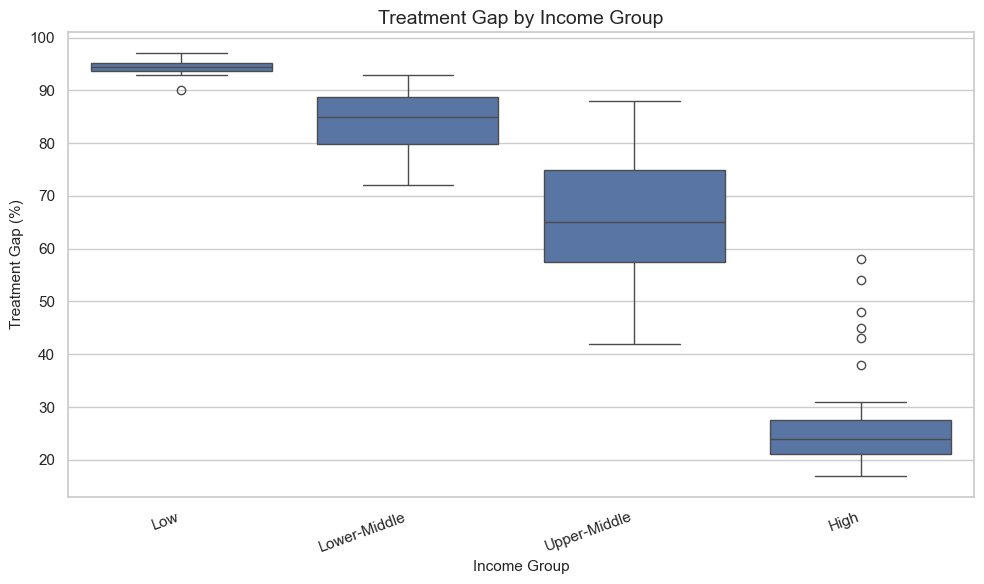

Kruskal-Wallis test: Treatment gap across income groups
Statistic: 77.7086
p-value: 0.0000
Result: Statistically significant at alpha = 0.05


In [26]:

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df_analysis,
    x="income_group",
    y="treatment_gap_pct"
)
ax.set_title("Treatment Gap by Income Group")
ax.set_xlabel("Income Group")
ax.set_ylabel("Treatment Gap (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

income_gap_groups = [
    df_analysis.loc[df_analysis["income_group"] == group, "treatment_gap_pct"]
    for group in df_analysis["income_group"].dropna().unique()
]

h_gap, p_kw_gap = kruskal(*income_gap_groups)
print_test_result("Kruskal-Wallis test: Treatment gap across income groups", h_gap, p_kw_gap)


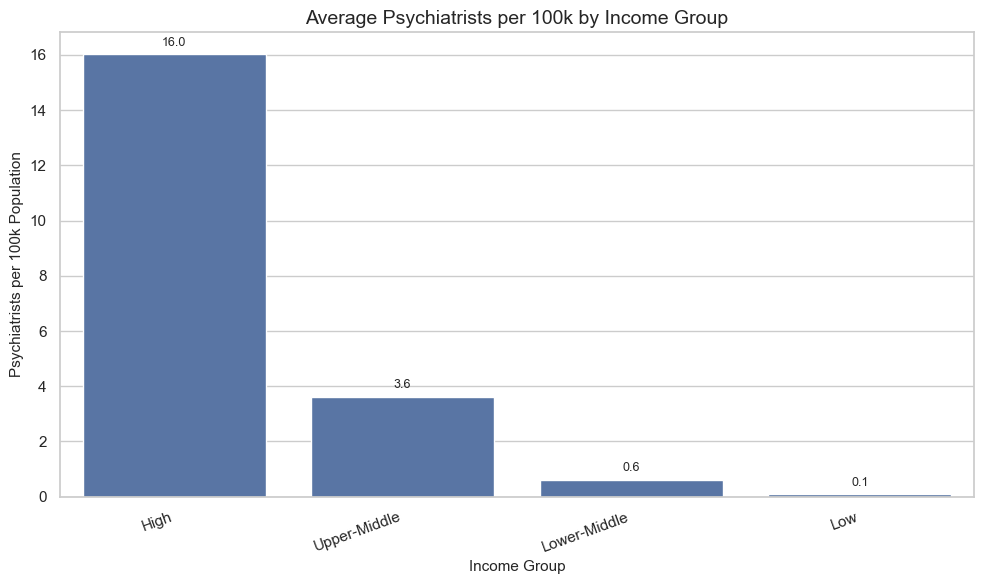

In [27]:
psych_availability = (
    df_analysis.groupby("income_group", as_index=False)["psychiatrists_per100k"]
    .mean()
    .sort_values("psychiatrists_per100k", ascending=False)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=psych_availability,
    x="income_group",
    y="psychiatrists_per100k"
)
add_value_labels(ax)
ax.set_title("Average Psychiatrists per 100k by Income Group")
ax.set_xlabel("Income Group")
ax.set_ylabel("Psychiatrists per 100k Population")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


In [28]:
highest_psych_row = psych_availability.iloc[0]

display(Markdown(
    f"**Psychiatrist availability finding.** `{highest_psych_row['income_group']}` countries have the highest average psychiatrist availability at **{highest_psych_row['psychiatrists_per100k']:.2f} per 100k population**, highlighting a clear resource advantage in specialist mental health capacity."
))


**Psychiatrist availability finding.** `High` countries have the highest average psychiatrist availability at **16.02 per 100k population**, highlighting a clear resource advantage in specialist mental health capacity.

### Interpretation

The next cell translates the income-group tables and tests into direct findings about crisis burden, treatment gaps, and psychiatrist availability.

In [29]:
crisis_sig = "statistically significant" if p_kw_crisis < 0.05 else "not statistically significant"
gap_sig = "statistically significant" if p_kw_gap < 0.05 else "not statistically significant"

highest_crisis_group = income_summary["mh_crisis_index"].idxmax()
highest_gap_group = income_summary["treatment_gap_pct"].idxmax()
highest_psych_group = income_summary["psychiatrists_per100k"].idxmax()

display(Markdown(
    f"**Finding.** `{highest_crisis_group}` countries had the highest average crisis index at "
    f"**{income_summary.loc[highest_crisis_group, 'mh_crisis_index']:.2f}**. "
    f"`{highest_gap_group}` countries had the highest average treatment gap at "
    f"**{income_summary.loc[highest_gap_group, 'treatment_gap_pct']:.2f}%**. "
    f"`{highest_psych_group}` countries had the highest psychiatrist availability at "
    f"**{income_summary.loc[highest_psych_group, 'psychiatrists_per100k']:.2f} per 100k**. "
    f"The crisis-index comparison across income groups returned **p = {p_kw_crisis:.4f}** "
    f"and the treatment-gap comparison returned **p = {p_kw_gap:.4f}**, making the group "
    f"differences **{crisis_sig}** for crisis burden and **{gap_sig}** for treatment gaps."
))

**Finding.** `Low` countries had the highest average crisis index at **81.38**. `Low` countries had the highest average treatment gap at **94.25%**. `High` countries had the highest psychiatrist availability at **16.02 per 100k**. The crisis-index comparison across income groups returned **p = 0.0000** and the treatment-gap comparison returned **p = 0.0000**, making the group differences **statistically significant** for crisis burden and **statistically significant** for treatment gaps.

# Bonus Use Case: Clustering and Segmentation
## Grouping countries into mental health system profiles

As a bonus, we use clustering to segment countries into profiles based on burden, capacity, and access variables. This is useful when policymakers want more than a simple ranking and instead want to identify groups of countries facing similar combinations of problems.

In [30]:

cluster_features = [
    "depression_pct",
    "anxiety_pct",
    "psychiatrists_per100k",
    "mh_budget_pct_health",
    "treatment_gap_pct",
    "mh_crisis_index",
    "mh_system_score"
]

cluster_df = df_analysis[["country", "region", "income_group"] + cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[cluster_features])

# Use 3 clusters for a simple, interpretable segmentation
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = cluster_df.groupby("cluster")[cluster_features].mean().round(2)
display(cluster_profile)


,depression_pct,anxiety_pct,psychiatrists_per100k,mh_budget_pct_health,treatment_gap_pct,mh_crisis_index,mh_system_score
cluster,,,,,,,
0,3.71,4.80,0.39,1.19,87.96,72.74,7.87
1,4.89,5.62,18.14,7.55,22.90,43.17,68.87
2,4.53,6.26,3.45,2.63,66.19,59.64,22.85


The next cell labels each cluster from the profile table so the segmentation result is described using the observed averages rather than generic placeholder text.

In [31]:

cluster_labels = {}
for cluster_id, row in cluster_profile.iterrows():
    burden = "high burden" if row["mh_crisis_index"] >= cluster_profile["mh_crisis_index"].median() else "lower burden"
    capacity = "stronger systems" if row["mh_system_score"] >= cluster_profile["mh_system_score"].median() else "weaker systems"
    access = "lower access gaps" if row["treatment_gap_pct"] <= cluster_profile["treatment_gap_pct"].median() else "wider access gaps"
    cluster_labels[cluster_id] = f"{burden}, {capacity}, {access}"

cluster_profile_with_labels = cluster_profile.copy()
cluster_profile_with_labels["profile_label"] = pd.Series(cluster_labels)
display(cluster_profile_with_labels)


,depression_pct,anxiety_pct,psychiatrists_per100k,mh_budget_pct_health,treatment_gap_pct,mh_crisis_index,mh_system_score,profile_label
cluster,,,,,,,,
0,3.71,4.80,0.39,1.19,87.96,72.74,7.87,"high burden, weaker systems, wider access gaps"
1,4.89,5.62,18.14,7.55,22.90,43.17,68.87,"lower burden, stronger systems, lower access gaps"
2,4.53,6.26,3.45,2.63,66.19,59.64,22.85,"high burden, stronger systems, lower access gaps"


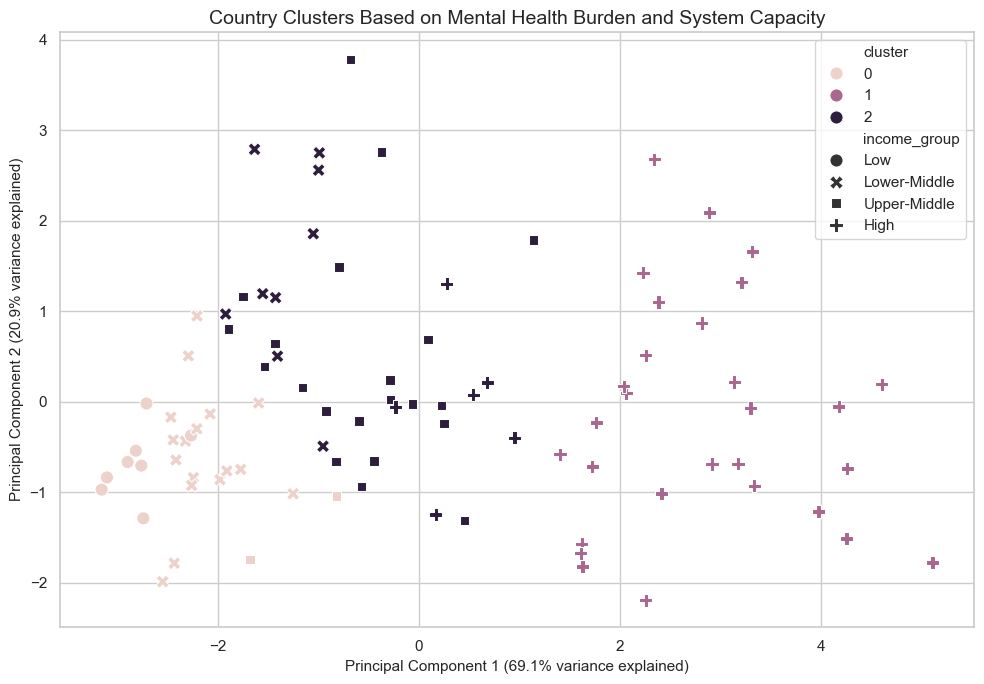

In [32]:

pca = PCA(n_components=2, random_state=RANDOM_STATE)
components = pca.fit_transform(X_scaled)

cluster_df["pca_1"] = components[:, 0]
cluster_df["pca_2"] = components[:, 1]

explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(10, 7))
ax = sns.scatterplot(
    data=cluster_df,
    x="pca_1",
    y="pca_2",
    hue="cluster",
    style="income_group",
    s=90
)
ax.set_title("Country Clusters Based on Mental Health Burden and System Capacity")
ax.set_xlabel(f"Principal Component 1 ({explained_var[0]:.1%} variance explained)")
ax.set_ylabel(f"Principal Component 2 ({explained_var[1]:.1%} variance explained)")
plt.tight_layout()
plt.show()


In [33]:

display(
    cluster_df[["country", "region", "income_group", "cluster"]]
    .sort_values(["cluster", "country"])
    .head(20)
)


,country,region,income_group,cluster
46,Azerbaijan,Europe,Upper-Middle,0
14,Bangladesh,S-E Asia,Lower-Middle,0
20,Bolivia,Americas,Lower-Middle,0
22,Cambodia,S-E Asia,Lower-Middle,0
7,Eswatini,Africa,Lower-Middle,0
2,Ethiopia,Africa,Low,0
44,Fiji,W. Pacific,Upper-Middle,0
11,Ghana,Africa,Lower-Middle,0
26,India,S-E Asia,Lower-Middle,0
29,Indonesia,S-E Asia,Lower-Middle,0


### Interpretation

The next cell prints a compact cluster narrative based on the actual cluster profiles and country assignments.

In [34]:
cluster_lines = []
for cluster_id, row in cluster_profile.iterrows():
    cluster_lines.append(
        f"- **Cluster {cluster_id}**: {cluster_labels[cluster_id]}. "
        f"Average crisis index = **{row['mh_crisis_index']:.2f}**, "
        f"system score = **{row['mh_system_score']:.2f}**, "
        f"treatment gap = **{row['treatment_gap_pct']:.2f}%**."
    )

display(Markdown("**Finding.** The clustering step produced the following country profiles:\n" + "\n".join(cluster_lines)))

**Finding.** The clustering step produced the following country profiles:
- **Cluster 0**: high burden, weaker systems, wider access gaps. Average crisis index = **72.74**, system score = **7.87**, treatment gap = **87.96%**.
- **Cluster 1**: lower burden, stronger systems, lower access gaps. Average crisis index = **43.17**, system score = **68.87**, treatment gap = **22.90%**.
- **Cluster 2**: high burden, stronger systems, lower access gaps. Average crisis index = **59.64**, system score = **22.85**, treatment gap = **66.19%**.

# Final Summary and Next Steps

The next cell builds a final summary from the computed results so the conclusion reflects what the notebook actually found after execution, not just what it analyzed.

In [35]:
top_region = regional_crisis.iloc[0]["region"]
top_region_score = regional_crisis.iloc[0]["mean"]

summary_md = f'''
# Final Summary and Next Steps

## Key Findings

- **{top_region}** recorded the highest average mental health crisis index at **{top_region_score:.2f}**.
- Daily social media use and depression rate showed **rho = {rho_dep:.3f}** with **p = {p_dep:.4f}**.
- Daily social media use and overall crisis index showed **rho = {rho_crisis:.3f}** with **p = {p_crisis:.4f}**.
- **{top_covid_region['region']}** had the highest regional post-COVID increase at **{top_covid_region['covid_mh_increase_pct']:.2f}%**.
- Policy status and law status were evaluated against treatment gaps using Mann-Whitney tests with **p = {p_policy:.4f}** and **p = {p_law:.4f}**.
- Income-group differences in crisis burden and treatment gaps were tested using Kruskal-Wallis, with **p = {p_kw_crisis:.4f}** and **p = {p_kw_gap:.4f}**.
- The clustering analysis separated countries into profiles ranging from higher-burden, weaker-system groups to lower-burden, stronger-system groups.

## Overall Conclusion

This dataset is useful for showing how mental health burden differs across regions, income groups, policy contexts, and digital environments. It supports both high-level dashboard analysis and deeper statistical comparison.

## Future Work

- Build a regression model to predict `mh_crisis_index`
- Add a choropleth world map for stronger dashboard presentation
- Test feature importance across economic, digital, and policy variables
- Extend the analysis with more age-specific mental health indicators if available
'''
display(Markdown(summary_md))


# Final Summary and Next Steps

## Key Findings

- **Africa** recorded the highest average mental health crisis index at **78.21**.
- Daily social media use and depression rate showed **rho = -0.009** with **p = 0.9341**.
- Daily social media use and overall crisis index showed **rho = 0.340** with **p = 0.0009**.
- **Africa** had the highest regional post-COVID increase at **74.07%**.
- Policy status and law status were evaluated against treatment gaps using Mann-Whitney tests with **p = 0.0000** and **p = 0.0000**.
- Income-group differences in crisis burden and treatment gaps were tested using Kruskal-Wallis, with **p = 0.0000** and **p = 0.0000**.
- The clustering analysis separated countries into profiles ranging from higher-burden, weaker-system groups to lower-burden, stronger-system groups.

## Overall Conclusion

This dataset is useful for showing how mental health burden differs across regions, income groups, policy contexts, and digital environments. It supports both high-level dashboard analysis and deeper statistical comparison.

## Future Work

- Build a regression model to predict `mh_crisis_index`
- Add a choropleth world map for stronger dashboard presentation
- Test feature importance across economic, digital, and policy variables
- Extend the analysis with more age-specific mental health indicators if available
